Cell 1: Mount Drive and set base paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/Deseaseoffish_project'
IMG_DIR    = f'{BASE_DIR}/Images'
MODELS_DIR = f'{BASE_DIR}/Models'

print("Images folder:")
!ls "$IMG_DIR"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images folder:
Test  Train  Train.csv


Cell 2: Inspect Train and Test folders (class names)

In [ ]:
IMG_DIR = '/content/drive/MyDrive/Deseaseoffish_project/Images'

print("Train contents:")
!ls "$IMG_DIR/Train"

print("\nTest contents:")
!ls "$IMG_DIR/Test"


Train contents:
'Bacterial diseases - Aeromoniasis'  'Healthy Fish'
'Bacterial gill disease'	     'Parasitic diseases'
'Bacterial Red disease'		     'Viral diseases White tail disease'
'Fungal diseases Saprolegniasis'

Test contents:
'Bacterial diseases - Aeromoniasis'  'Healthy Fish'
'Bacterial gill disease'	     'Parasitic diseases'
'Bacterial Red disease'		     'Viral diseases White tail disease'
'Fungal diseases Saprolegniasis'


Cell 3: Import libraries and ensure Models directory exists

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_DIR    = '/content/drive/MyDrive/Deseaseoffish_project/Images'
MODELS_DIR = '/content/drive/MyDrive/Deseaseoffish_project/Models'
os.makedirs(MODELS_DIR, exist_ok=True)

print("Train folders:")
!ls "$IMG_DIR/Train"
print("\nTest folders:")
!ls "$IMG_DIR/Test"


Train folders:
'Bacterial diseases - Aeromoniasis'  'Healthy Fish'
'Bacterial gill disease'	     'Parasitic diseases'
'Bacterial Red disease'		     'Viral diseases White tail disease'
'Fungal diseases Saprolegniasis'

Test folders:
'Bacterial diseases - Aeromoniasis'  'Healthy Fish'
'Bacterial gill disease'	     'Parasitic diseases'
'Bacterial Red disease'		     'Viral diseases White tail disease'
'Fungal diseases Saprolegniasis'


Cell 4:Data generators (train / validation / test with augmentation)


In [ ]:
import os

img_size = (224, 224)
batch_size = 32

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Train + validation from Train folder (80/20 split)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(IMG_DIR, 'Train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    directory=os.path.join(IMG_DIR, 'Train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    subset='validation'
)

# Test from Test folder (only for final evaluation)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    directory=os.path.join(IMG_DIR, 'Test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 1401 images belonging to 7 classes.
Found 349 images belonging to 7 classes.
Found 698 images belonging to 7 classes.
Classes: {'Bacterial Red disease': 0, 'Bacterial diseases - Aeromoniasis': 1, 'Bacterial gill disease': 2, 'Fungal diseases Saprolegniasis': 3, 'Healthy Fish': 4, 'Parasitic diseases': 5, 'Viral diseases White tail disease': 6}


Cell 5: Visualize sample training images (sanity check)

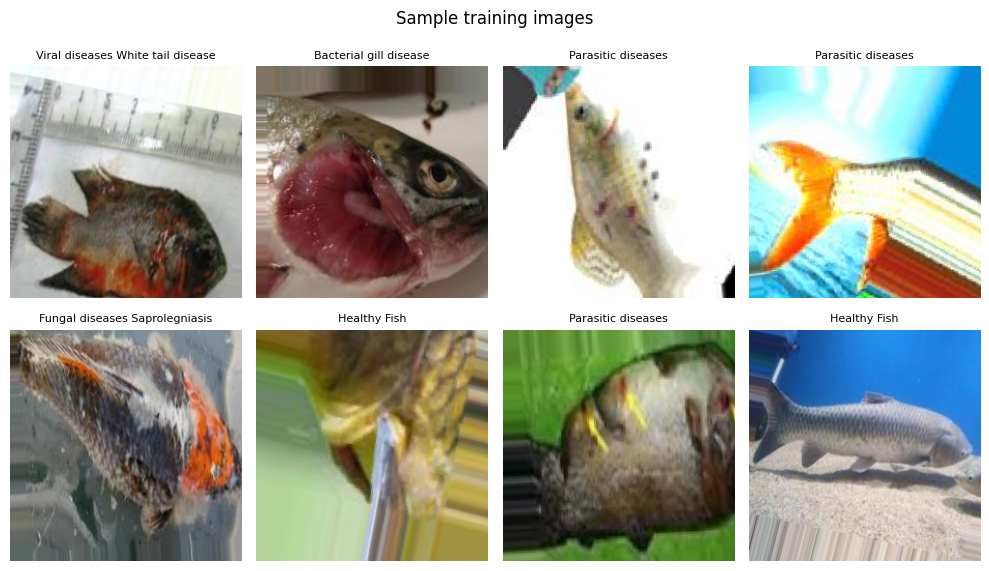

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_batch, y_batch = next(train_generator)
class_indices = {v:k for k,v in train_generator.class_indices.items()}

plt.figure(figsize=(10,6))
for i in range(8):
    ax = plt.subplot(2,4,i+1)
    img = x_batch[i]
    label_idx = np.argmax(y_batch[i])
    plt.imshow((img + 1.0) / 2.0)  # roughly undo preprocess_input
    plt.title(class_indices[label_idx], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample training images')
plt.tight_layout()
plt.show()


Cell 6: MobileNetV2 model definition (lightweight CNN)

In [ ]:
base_model = MobileNetV2(
    input_shape=img_size + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # first train only new head

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

cell 7: Train and fine-tune MobileNetV2, then save best model

In [ ]:
checkpoint_path = os.path.join(MODELS_DIR, 'mobilenetv2_fish_best.h5')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy (frozen base): {test_acc:.3f}")

# Optional: fine-tune top layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-40]:   # freeze all but last 40 layers
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks
)

test_loss_ft, test_acc_ft = model.evaluate(test_generator)
print(f"Test accuracy after fine-tuning: {test_acc_ft:.3f}")

# Save final model
final_model_path = os.path.join(MODELS_DIR, 'mobilenetv2_fish_final.h5')
model.save(final_model_path)
print("✅ MobileNetV2 image model saved at:", final_model_path)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.2705 - loss: 2.1606 

44/44 ━━━━━━━━━━━━━━━━━━━━ 847s 19s/step - accuracy: 0.2712 - loss: 2.1562 - val_accuracy: 0.4613 - val_loss: 1.4664
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4595 - loss: 1.5009

44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.4601 - loss: 1.4991 - val_accuracy: 0.5473 - val_loss: 1.2353
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5836 - loss: 1.1668

44/44 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5835 - loss: 1.1672 - val_accuracy: 0.5702 - val_loss: 1.1448
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6321 - loss: 1.0210

44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6321 - loss: 1.0215 - val_accuracy: 0.6103 - val_loss: 1.0866
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6728 - loss: 0.9006 - val_accuracy: 0.5759 - val_loss: 1.1001
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6914 - loss: 0.8575

44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6916 - loss: 0.8575 - val_accuracy: 0.6390 - val_loss: 1.0051
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.7039 - loss: 0.8384 - val_accuracy: 0.6189 - val_loss: 1.0639
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7085 - loss: 0.7808

44/44 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7088 - loss: 0.7807 - val_accuracy: 0.6734 - val_loss: 0.9558
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7571 - loss: 0.7094 - val_accuracy: 0.6476 - val_loss: 1.0070
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7485 - loss: 0.6865 - val_accuracy: 0.5874 - val_loss: 1.0958
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7665 - loss: 0.7227 - val_accuracy: 0.6390 - val_loss: 1.0383
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7865 - loss: 0.6511 - val_accuracy: 0.6275 - val_loss: 0.9608
Epoch 13/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.7845 - loss: 0.6185 - val_accuracy: 0.6705 - val_loss: 0.9629
22/22 ━━━━━━━━━━━━━━━━━━━━ 268s 13s/step - accuracy: 0.7564 - loss: 0.7570
Test accuracy (frozen base): 0.766
Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.6604 - loss: 0.9926 - val_accuracy: 0.5817 - val_loss: 1.2551
Epoch 2/

Test accuracy after fine-tuning: 0.723
✅ MobileNetV2 image model saved at: /content/drive/MyDrive/Deseaseoffish_project/Models/mobilenetv2_fish_final.h5


Cell 10:EfficientNetB0 model (second lightweight CNN)

In [ ]:
# EfficientNetB0 model: definition, training, evaluation

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EfficientNetB0 backbone
base_model_e = EfficientNetB0(
    input_shape=img_size + (3,),
    include_top=False,
    weights='imagenet'
)
base_model_e.trainable = False  # first train only new head

inputs_e = layers.Input(shape=img_size + (3,))
y = base_model_e(inputs_e, training=False)
y = layers.GlobalAveragePooling2D()(y)
y = layers.Dropout(0.3)(y)
outputs_e = layers.Dense(num_classes, activation='softmax')(y)
model_e = models.Model(inputs_e, outputs_e)

model_e.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_path_e = os.path.join(MODELS_DIR, 'efficientnetb0_fish_best.h5')
callbacks_e = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path_e, monitor='val_loss', save_best_only=True)
]

history_e = model_e.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks_e
)

# Evaluate on test set
test_loss_e, test_acc_e = model_e.evaluate(test_generator)
print(f"EfficientNetB0 test accuracy (frozen base): {test_acc_e:.3f}")

# Optional: fine-tune top layers of EfficientNetB0
base_model_e.trainable = True
for layer in base_model_e.layers[:-40]:
    layer.trainable = False

model_e.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_e_ft = model_e.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks_e
)

test_loss_e_ft, test_acc_e_ft = model_e.evaluate(test_generator)
print(f"EfficientNetB0 test accuracy after fine-tuning: {test_acc_e_ft:.3f}")

# Save final EfficientNetB0 model
final_model_path_e = os.path.join(MODELS_DIR, 'efficientnetb0_fish_final.h5')
model_e.save(final_model_path_e)
print("✅ EfficientNetB0 image model saved at:", final_model_path_e)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.1342 - loss: 1.9845 

44/44 ━━━━━━━━━━━━━━━━━━━━ 790s 18s/step - accuracy: 0.1342 - loss: 1.9846 - val_accuracy: 0.1433 - val_loss: 1.9510
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.1583 - loss: 1.9718 - val_accuracy: 0.1433 - val_loss: 1.9679
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 169s 4s/step - accuracy: 0.1300 - loss: 1.9783 - val_accuracy: 0.1433 - val_loss: 1.9830
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.1475 - loss: 1.9962 - val_accuracy: 0.1433 - val_loss: 1.9607
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1480 - loss: 1.9780

44/44 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.1477 - loss: 1.9779 - val_accuracy: 0.1605 - val_loss: 1.9455
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.1511 - loss: 1.9670 - val_accuracy: 0.1490 - val_loss: 1.9548
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.1337 - loss: 1.9753 - val_accuracy: 0.1433 - val_loss: 1.9528
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.1640 - loss: 1.9675 - val_accuracy: 0.1461 - val_loss: 1.9530
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.1614 - loss: 1.9633 - val_accuracy: 0.1433 - val_loss: 1.9575
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.1603 - loss: 1.9694 - val_accuracy: 0.1433 - val_loss: 1.9585
22/22 ━━━━━━━━━━━━━━━━━━━━ 234s 11s/step - accuracy: 0.2294 - loss: 1.9211
EfficientNetB0 test accuracy (frozen base): 0.153
Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.1551 - loss: 2.0030 - val_accuracy: 0.1433 - val_loss: 1.9

44/44 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.1685 - loss: 1.9498 - val_accuracy: 0.1461 - val_loss: 1.9367
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1999 - loss: 1.9351

44/44 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.1999 - loss: 1.9350 - val_accuracy: 0.1605 - val_loss: 1.9296
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1939 - loss: 1.9180

44/44 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.1937 - loss: 1.9180 - val_accuracy: 0.1920 - val_loss: 1.9207
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1787 - loss: 1.9044

44/44 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.1790 - loss: 1.9045 - val_accuracy: 0.2178 - val_loss: 1.9056
22/22 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.1288 - loss: 1.8888


EfficientNetB0 test accuracy after fine-tuning: 0.232
✅ EfficientNetB0 image model saved at: /content/drive/MyDrive/Deseaseoffish_project/Models/efficientnetb0_fish_final.h5


Cell 11:Confusion matrix and classification report for (EfficientNetB0)

22/22 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step

EfficientNetB0 classification report:

                                   precision    recall  f1-score   support

            Bacterial Red disease       0.11      0.12      0.12       100
Bacterial diseases - Aeromoniasis       0.00      0.00      0.00       100
           Bacterial gill disease       0.22      0.20      0.21       100
   Fungal diseases Saprolegniasis       0.00      0.00      0.00       100
                     Healthy Fish       0.27      0.58      0.36       100
               Parasitic diseases       0.75      0.03      0.06       100
Viral diseases White tail disease       0.25      0.70      0.37        98

                         accuracy                           0.23       698
                        macro avg       0.23      0.23      0.16       698
                     weighted avg       0.23      0.23      0.16       698



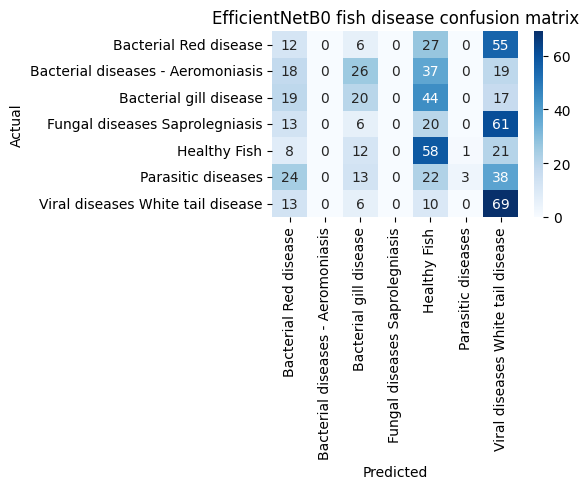

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the fine-tuned EfficientNetB0 model: model_e
test_generator.reset()
probs_e = model_e.predict(test_generator)
y_pred_e = np.argmax(probs_e, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nEfficientNetB0 classification report:\n")
print(classification_report(y_true, y_pred_e, target_names=class_names, zero_division=0))

cm_e = confusion_matrix(y_true, y_pred_e)
plt.figure(figsize=(6,5))
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetB0 fish disease confusion matrix')
plt.tight_layout()
plt.show()


Cell 12: Accuracy/loss plots(EfficientNetB0)

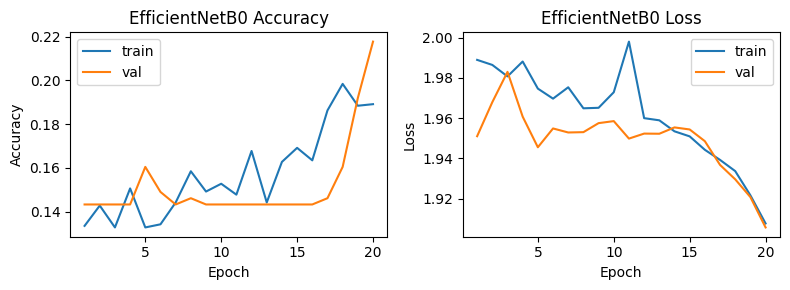

In [ ]:
import matplotlib.pyplot as plt

# Combine histories if you want continuous plots
acc_e = history_e.history['accuracy'] + history_e_ft.history['accuracy']
val_acc_e = history_e.history['val_accuracy'] + history_e_ft.history['val_accuracy']
loss_e = history_e.history['loss'] + history_e_ft.history['loss']
val_loss_e = history_e.history['val_loss'] + history_e_ft.history['val_loss']

epochs_e = range(1, len(acc_e) + 1)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(epochs_e, acc_e, label='train')
plt.plot(epochs_e, val_acc_e, label='val')
plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_e, loss_e, label='train')
plt.plot(epochs_e, val_loss_e, label='val')
plt.title('EfficientNetB0 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Cell 8:Accuracy/loss plots(MobileNetV2)

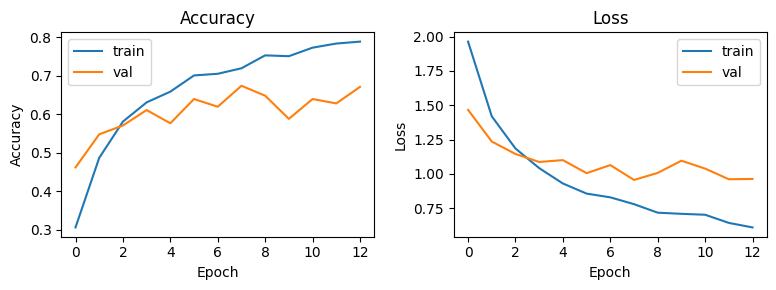

In [ ]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Cell 9:Classification report+Confusion Matrix(MobileNetv2)

22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step

Classification report:

                                   precision    recall  f1-score   support

            Bacterial Red disease       0.92      0.60      0.73       100
Bacterial diseases - Aeromoniasis       0.69      0.79      0.74       100
           Bacterial gill disease       0.93      0.84      0.88       100
   Fungal diseases Saprolegniasis       0.76      0.58      0.66       100
                     Healthy Fish       0.80      0.96      0.87       100
               Parasitic diseases       0.98      0.41      0.58       100
Viral diseases White tail disease       0.46      0.89      0.60        98

                         accuracy                           0.72       698
                        macro avg       0.79      0.72      0.72       698
                     weighted avg       0.79      0.72      0.72       698



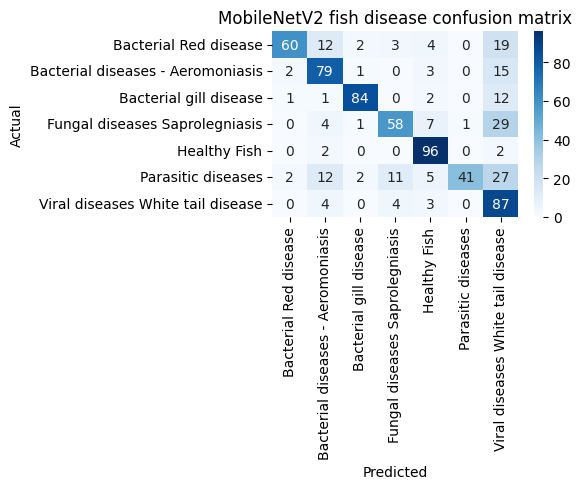

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
test_generator.reset()
probs = model.predict(test_generator)
y_pred = np.argmax(probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MobileNetV2 fish disease confusion matrix')
plt.tight_layout()
plt.show()


In [ ]:
 Download trained MobileNetV2 model (.h5) to local machine
from google.colab import files

files.download('/content/drive/MyDrive/Deseaseoffish_project/Models/mobilenetv2_fish_final.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 13: InceptionV3 model: definition, training, evaluation

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# If you want, you can use a larger input size (e.g. 299, 299) for InceptionV3.
# To keep life simple and reuse your existing generators, we will stay with 224x224
# (this is allowed when include_top=False). [web:564][web:569]

# InceptionV3 backbone
base_model_i = InceptionV3(
    input_shape=img_size + (3,),   # img_size = (224, 224)
    include_top=False,
    weights='imagenet'
)
base_model_i.trainable = False  # first train only new head

# New classification head
inputs_i = layers.Input(shape=img_size + (3,))
z = base_model_i(inputs_i, training=False)
z = layers.GlobalAveragePooling2D()(z)
z = layers.Dropout(0.3)(z)
outputs_i = layers.Dense(num_classes, activation='softmax')(z)
model_i = models.Model(inputs_i, outputs_i)

model_i.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_i.summary()

# Callbacks for InceptionV3
checkpoint_path_i = os.path.join(MODELS_DIR, 'inceptionv3_fish_best.h5')
callbacks_i = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path_i, monitor='val_loss', save_best_only=True)
]

# Stage 1: train head with frozen InceptionV3 base
history_i = model_i.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks_i
)

# Evaluate frozen-base InceptionV3
test_loss_i, test_acc_i = model_i.evaluate(test_generator)
print(f"InceptionV3 test accuracy (frozen base): {test_acc_i:.3f}")

# Stage 2: fine-tune top layers of InceptionV3
base_model_i.trainable = True

# Freeze most layers, unfreeze last ~40 (you can adjust this number)
for layer in base_model_i.layers[:-40]:
    layer.trainable = False

model_i.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_i_ft = model_i.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks_i
)

test_loss_i_ft, test_acc_i_ft = model_i.evaluate(test_generator)
print(f"InceptionV3 test accuracy after fine-tuning: {test_acc_i_ft:.3f}")

# Save final InceptionV3 model
final_model_path_i = os.path.join(MODELS_DIR, 'inceptionv3_fish_final.h5')
model_i.save(final_model_path_i)
print("✅ InceptionV3 image model saved at:", final_model_path_i)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,817,127 (83.23 MB)

 Trainable params: 14,343 (56.03 KB)

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 334s 8s/step - accuracy: 0.8561 - loss: 0.4630 - val_accuracy: 0.7020 - val_loss: 0.9186
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9200 - loss: 0.2900

44/44 ━━━━━━━━━━━━━━━━━━━━ 309s 7s/step - accuracy: 0.9199 - loss: 0.2903 - val_accuracy: 0.7650 - val_loss: 0.7332
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 303s 7s/step - accuracy: 0.9523 - loss: 0.2033 - val_accuracy: 0.7622 - val_loss: 0.7773
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.9621 - loss: 0.1491 - val_accuracy: 0.7765 - val_loss: 0.7533
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9754 - loss: 0.1009

44/44 ━━━━━━━━━━━━━━━━━━━━ 298s 7s/step - accuracy: 0.9753 - loss: 0.1013 - val_accuracy: 0.7966 - val_loss: 0.6716
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 287s 6s/step - accuracy: 0.9781 - loss: 0.1090 - val_accuracy: 0.7650 - val_loss: 0.7174
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.9836 - loss: 0.0756 - val_accuracy: 0.7880 - val_loss: 0.7022
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9855 - loss: 0.0635

44/44 ━━━━━━━━━━━━━━━━━━━━ 287s 7s/step - accuracy: 0.9855 - loss: 0.0636 - val_accuracy: 0.8166 - val_loss: 0.6063
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 316s 7s/step - accuracy: 0.9856 - loss: 0.0610 - val_accuracy: 0.8166 - val_loss: 0.6676
22/22 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.9677 - loss: 0.1332


InceptionV3 test accuracy after fine-tuning: 0.974
✅ InceptionV3 image model saved at: /content/drive/MyDrive/Deseaseoffish_project/Models/inceptionv3_fish_final.h5


Cell 14: Accuracy/plots(InceptionV3)

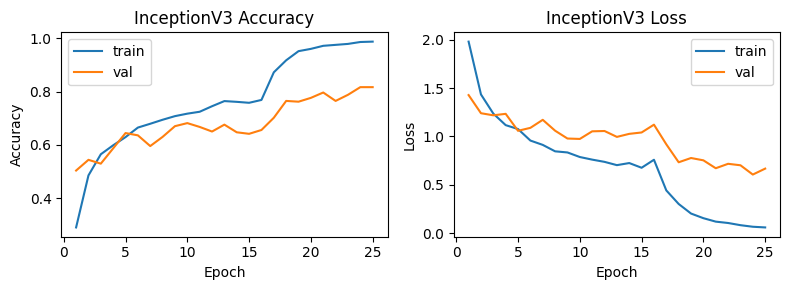

In [ ]:
# Combine histories
acc_i = history_i.history['accuracy'] + history_i_ft.history['accuracy']
val_acc_i = history_i.history['val_accuracy'] + history_i_ft.history['val_accuracy']
loss_i = history_i.history['loss'] + history_i_ft.history['loss']
val_loss_i = history_i.history['val_loss'] + history_i_ft.history['val_loss']

epochs_i = range(1, len(acc_i) + 1)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(epochs_i, acc_i, label='train')
plt.plot(epochs_i, val_acc_i, label='val')
plt.title('InceptionV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_i, loss_i, label='train')
plt.plot(epochs_i, val_loss_i, label='val')
plt.title('InceptionV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Cell 15:Confusion matrix and classification report for InceptionV3

22/22 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step

InceptionV3 classification report:

                                   precision    recall  f1-score   support

            Bacterial Red disease       0.98      0.98      0.98       100
Bacterial diseases - Aeromoniasis       0.98      0.96      0.97       100
           Bacterial gill disease       0.97      0.97      0.97       100
   Fungal diseases Saprolegniasis       0.99      0.94      0.96       100
                     Healthy Fish       0.98      1.00      0.99       100
               Parasitic diseases       0.96      0.99      0.98       100
Viral diseases White tail disease       0.96      0.98      0.97        98

                         accuracy                           0.97       698
                        macro avg       0.97      0.97      0.97       698
                     weighted avg       0.97      0.97      0.97       698



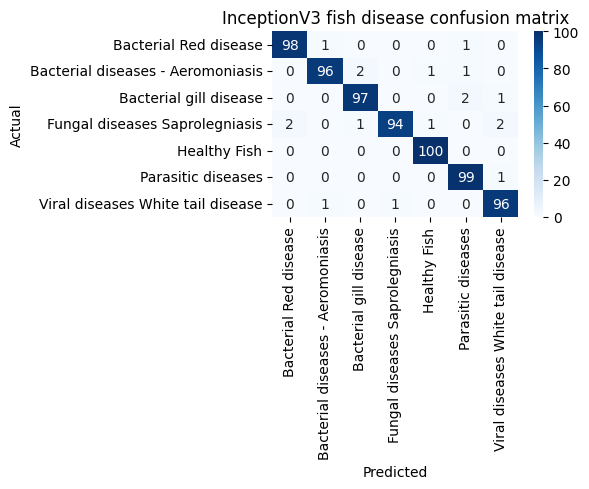

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_generator.reset()
probs_i = model_i.predict(test_generator)
y_pred_i = np.argmax(probs_i, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nInceptionV3 classification report:\n")
print(classification_report(y_true, y_pred_i, target_names=class_names, zero_division=0))

cm_i = confusion_matrix(y_true, y_pred_i)
plt.figure(figsize=(6,5))
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('InceptionV3 fish disease confusion matrix')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Deseaseoffish_project/Models/inceptionv3_fish_final.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model

MODEL_PATH_I = '/content/drive/MyDrive/Deseaseoffish_project/Models/inceptionv3_fish_final.h5'
model_i = load_model(MODEL_PATH_I)


In [ ]:
test_generator.reset()
probs_i = model_i.predict(test_generator)  # softmax probabilities
y_pred_i = np.argmax(probs_i, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())


22/22 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step


InceptionV3 – per-class F1-score bar chart

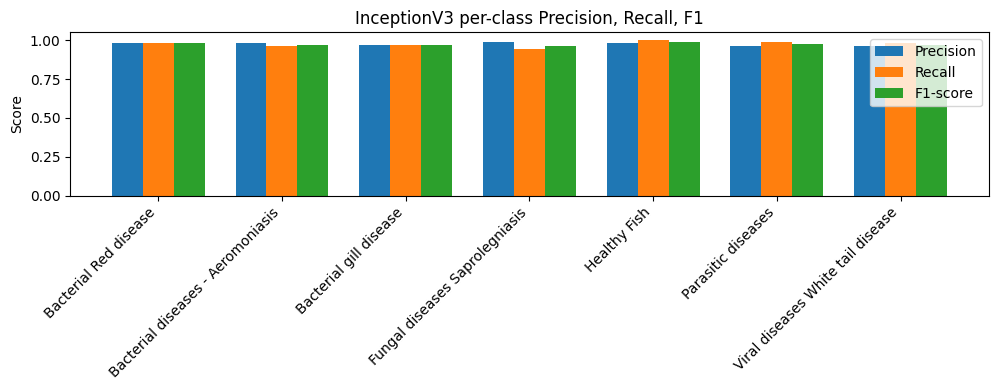

In [ ]:


from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

# y_true, y_pred_i already defined above
prec_i, rec_i, f1_i, support_i = precision_recall_fscore_support(
    y_true, y_pred_i, labels=range(len(class_names)), zero_division=0
)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10,4))
plt.bar(x - width, prec_i, width, label='Precision')
plt.bar(x,        rec_i,  width, label='Recall')
plt.bar(x + width, f1_i,  width, label='F1-score')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('InceptionV3 per-class Precision, Recall, F1')
plt.legend()
plt.tight_layout()
plt.show()


ROC‑like one‑vs‑rest curves (macro view)

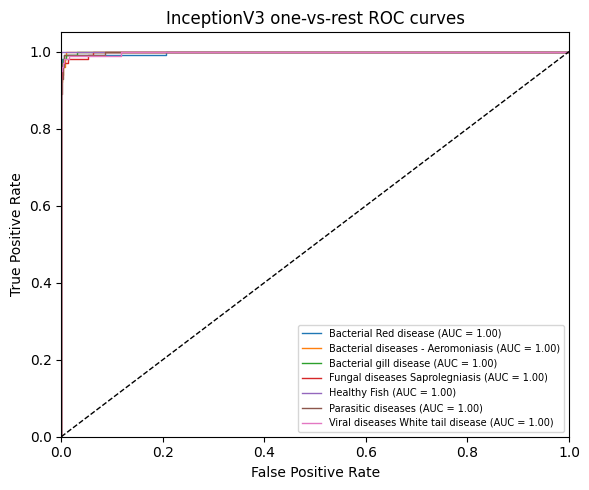

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = len(class_names)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))
# probs_i already computed: shape (N, n_classes)

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_i[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('InceptionV3 one-vs-rest ROC curves')
plt.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()


Misclassified examples (qualitative analysis)

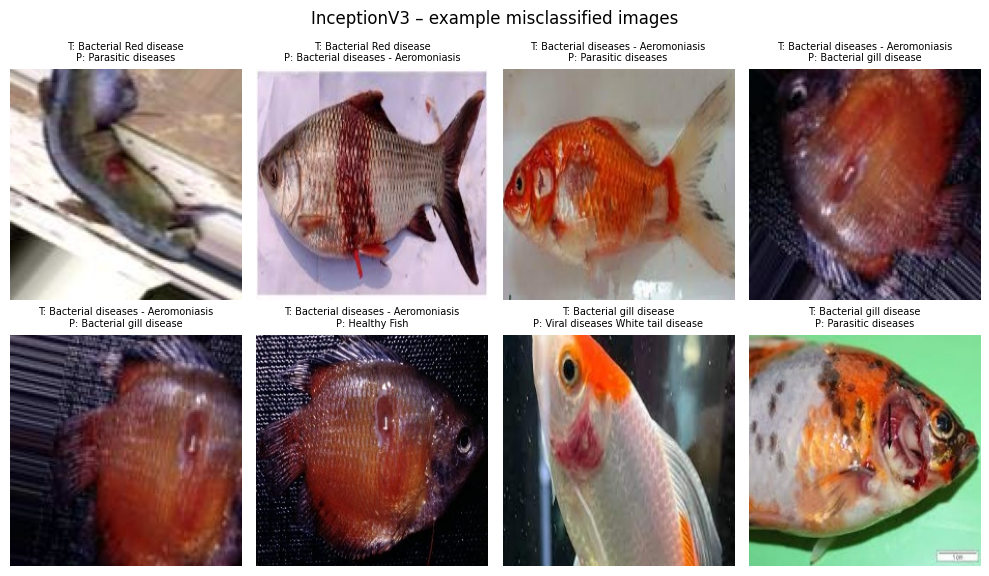

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# indices where model is wrong
wrong_idx = np.where(y_pred_i != y_true)[0]

# reload images from generator (must have shuffle=False)
test_generator.reset()
x_test, _ = next(test_generator)  # this only loads first batch
# For many images, better load from disk paths; for simplicity, use generator indexes

num_show = min(8, len(wrong_idx))
plt.figure(figsize=(10,6))

for j in range(num_show):
    i = wrong_idx[j]
    # generator.filenames gives relative paths
    img_path = test_generator.filepaths[i]
    img = plt.imread(img_path)

    plt.subplot(2,4,j+1)
    plt.imshow(img)
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred_i[i]]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=7)
    plt.axis('off')

plt.suptitle('InceptionV3 – example misclassified images')
plt.tight_layout()
plt.show()
